# 01 – Analiza exploratorie (EDA) și curățarea datelor
**Proiect:** predicția prețului mașinilor second-hand · **Autor:** Cristiana-Raluca Costache

**Întrebarea de business:** *cât ar putea valora această mașină?* Vreau un model care estimează `priceUSD`
din caracteristicile mașinii. Este o problemă de **regresie**: modelul prezice un număr, nu o clasă.

În acest notebook:
1. mă uit la date: dimensiune, tipuri, valori lipsă;
2. analizez variabila țintă `priceUSD`;
3. caut valori extreme sau imposibile (preț, an, kilometraj, motor);
4. văd ce relație au coloanele cu prețul;
5. aplic curățarea (`src/data_cleaning.py`) și caracteristicile noi (`src/feature_engineering.py`) și verific rezultatul.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")        # ca să pot importa scripturile proiectului
from config import DATA_PATH, REFERENCE_YEAR
from data_cleaning import clean_data
from feature_engineering import add_features

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.1f}".format)

## 1. Prima privire asupra datelor

In [3]:
raw = pd.read_csv(DATA_PATH)
print("Rânduri x coloane:", raw.shape)
raw.head()

Rânduri x coloane: (56244, 12)


,make,model,priceUSD,year,condition,mileage(kilometers),fuel_type,volume(cm3),color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,"162,000.0",petrol,"1,500.0",burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,"120,000.0",petrol,"1,300.0",black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,"61,000.0",petrol,"1,500.0",silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,"265,000.0",diesel,"1,400.0",white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,"97,183.0",diesel,"1,400.0",gray,mechanics,front-wheel drive,B


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make                 56244 non-null  str    
 1   model                56244 non-null  str    
 2   priceUSD             56244 non-null  int64  
 3   year                 56244 non-null  int64  
 4   condition            56244 non-null  str    
 5   mileage(kilometers)  56244 non-null  float64
 6   fuel_type            56244 non-null  str    
 7   volume(cm3)          56197 non-null  float64
 8   color                56244 non-null  str    
 9   transmission         56244 non-null  str    
 10  drive_unit           54339 non-null  str    
 11  segment              50953 non-null  str    
dtypes: float64(2), int64(2), str(8)
memory usage: 5.1 MB


In [5]:
missing = raw.isna().sum()
pd.DataFrame({"lipsă": missing, "%": (missing / len(raw) * 100).round(2)}).query("lipsă > 0")

,lipsă,%
volume(cm3),47,0.1
drive_unit,1905,3.4
segment,5291,9.4


In [6]:
print("Rânduri duplicate:", raw.duplicated().sum())
numeric_cols = raw.select_dtypes("number").columns.tolist()
categorical_cols = [c for c in raw.columns if c not in numeric_cols]
print("Numerice:", numeric_cols)
print("Categorice:", categorical_cols)

Rânduri duplicate: 87
Numerice: ['priceUSD', 'year', 'mileage(kilometers)', 'volume(cm3)']
Categorice: ['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']


In [6]:
# Câte valori distincte are fiecare coloană categorică?
raw[categorical_cols].nunique().sort_values(ascending=False)

model           1034
make              96
color             13
segment            9
drive_unit         4
condition          3
fuel_type          3
transmission       2
dtype: int64

In [7]:
for col in ["condition", "fuel_type", "transmission", "drive_unit", "segment", "color"]:
    print(f"--- {col} ---")
    print(raw[col].value_counts(dropna=False).to_string(), "\n")

--- condition ---
condition
with mileage    55278
with damage       512
for parts         454 

--- fuel_type ---
fuel_type
petrol        36405
diesel        19792
electrocar       47 

--- transmission ---
transmission
mechanics    36056
auto         20188 

--- drive_unit ---
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive                5890
part-time four-wheel drive     3597
NaN                            1905 

--- segment ---
segment
D      12605
C      10617
J       8629
M       6313
E       6274
NaN     5291
B       4393
F        896
S        765
A        461 

--- color ---
color
black       12385
silver      10075
blue         8083
gray         5807
white        5292
green        3911
other        3397
red          2744
burgundy     2026
brown        1349
purple        625
yellow        317
orange        233 



**Ce observ:**
- **56.244 de anunțuri** și 12 coloane: 4 numerice, 8 text.
- **Numele coloanelor** `mileage(kilometers)` și `volume(cm3)` au paranteze și sunt incomode în cod. Le redenumesc în `mileage_km` și `volume_cm3`.
- **Valori lipsă:**
  - `segment` lipsește la 5.291 de anunțuri (9%) și `drive_unit` la 1.905;
  - `volume(cm3)` lipsește la 47 de anunțuri, **exact cele 47 de mașini electrice**, care nu au capacitate cilindrică.
- **87 de rânduri duplicate**, probabil anunțuri publicate de două ori.
- `model` are **peste 1.000 de valori distincte**. Asta contează la alegerea encoder-ului.
- Categoriile par deja scrise consecvent (litere mici), dar le standardizez oricum, ca protecție pentru date noi.

## 2. Variabila țintă: `priceUSD`

In [8]:
raw["priceUSD"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])

count    56,244.0
mean      7,415.5
std       8,317.0
min          48.0
1%          333.0
5%          700.0
25%       2,350.0
50%       5,350.0
75%       9,807.5
95%      20,000.0
99%      39,728.5
max     235,235.0
Name: priceUSD, dtype: float64

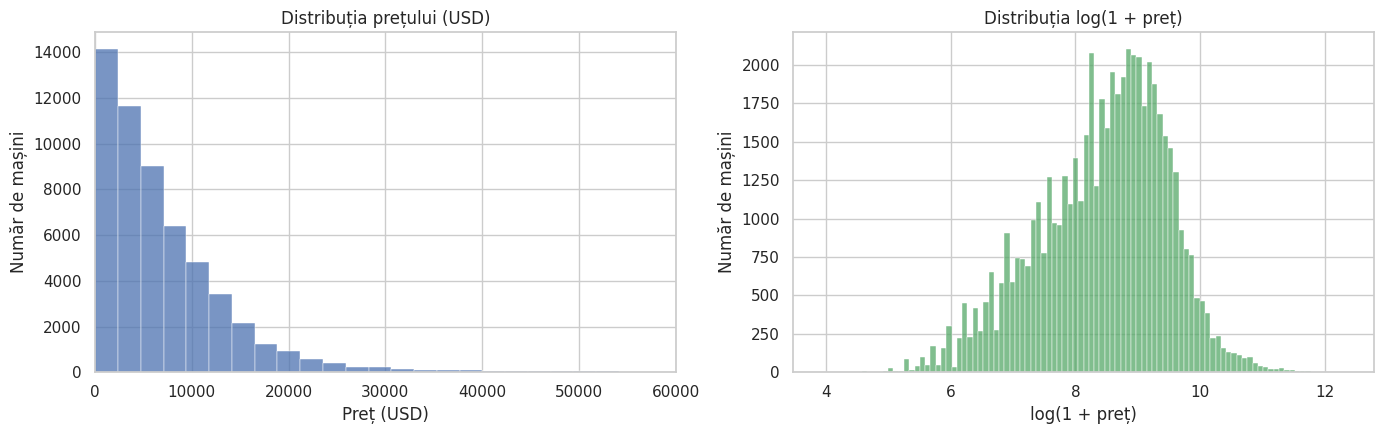

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(raw["priceUSD"], bins=100, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuția prețului (USD)")
axes[0].set_xlabel("Preț (USD)"); axes[0].set_ylabel("Număr de mașini")
axes[0].set_xlim(0, 60000)

sns.histplot(np.log1p(raw["priceUSD"]), bins=100, ax=axes[1], color="#55A868")
axes[1].set_title("Distribuția log(1 + preț)")
axes[1].set_xlabel("log(1 + preț)"); axes[1].set_ylabel("Număr de mașini")
plt.tight_layout(); plt.show()

**Ce observ:**
- Prețul median este **5.350 $**, dar media este mai mare (~7.400 $), trasă în sus de câteva mașini scumpe.
  Distribuția este foarte **asimetrică spre dreapta**.
- După **logaritmare**, distribuția arată aproape „normal”. De aceea voi antrena modelele pe **log(preț)**.
  Un model învață mai ușor diferențe relative („cu 20% mai scumpă”) decât absolute.
- Există prețuri **suspect de mici** (minim 48 $; 370 de anunțuri sub 300 $) și câteva **foarte mari** (maxim 235.235 $).

## 3. Valori extreme și imposibile

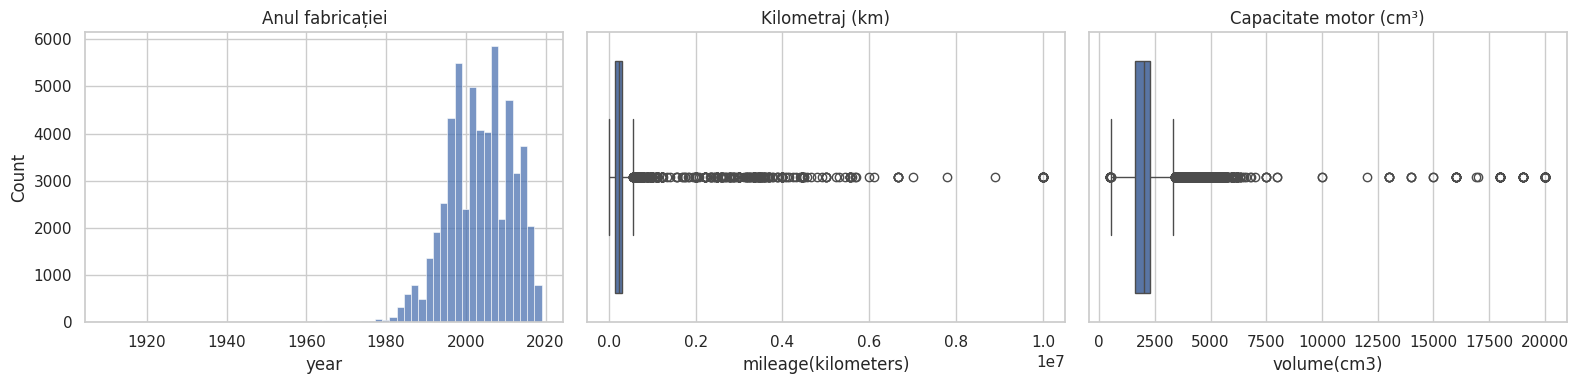

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(raw["year"], bins=60, ax=axes[0]); axes[0].set_title("Anul fabricației")
sns.boxplot(x=raw["mileage(kilometers)"], ax=axes[1]); axes[1].set_title("Kilometraj (km)")
sns.boxplot(x=raw["volume(cm3)"], ax=axes[2]); axes[2].set_title("Capacitate motor (cm³)")
plt.tight_layout(); plt.show()

In [11]:
checks = {
    "preț < 100 $": (raw["priceUSD"] < 100).sum(),
    "preț > 100.000 $": (raw["priceUSD"] > 100_000).sum(),
    "an < 1980": (raw["year"] < 1980).sum(),
    "kilometraj > 1.000.000 km": (raw["mileage(kilometers)"] > 1_000_000).sum(),
    "kilometraj < 1.000 km la mașini > 2 ani": ((raw["mileage(kilometers)"] < 1000) & (REFERENCE_YEAR - raw["year"] > 2)).sum(),
    "motor > 8.000 cm³": (raw["volume(cm3)"] > 8000).sum(),
}
pd.Series(checks, name="număr anunțuri").to_frame()

,număr anunțuri
preț < 100 $,2
preț > 100.000 $,33
an < 1980,258
kilometraj > 1.000.000 km,364
kilometraj < 1.000 km la mașini > 2 ani,2454
motor > 8.000 cm³,88


In [12]:
# Cum arată aceste valori ciudate?
print("Cele mai mari kilometraje:", sorted(raw["mileage(kilometers)"].nlargest(8).tolist()))
print("\nMotoare > 8000 cm³:")
print(raw.loc[raw["volume(cm3)"] > 8000, ["make", "model", "year", "volume(cm3)"]].head(8).to_string())
print("\nMașini foarte vechi:")
print(raw.loc[raw["year"] < 1960, ["make", "model", "year", "priceUSD"]].to_string())

Cele mai mari kilometraje: [9999999.0, 9999999.0, 9999999.0, 9999999.0, 9999999.0, 9999999.0, 9999999.0, 9999999.0]

Motoare > 8000 cm³:
         make model  year  volume(cm3)
81      mazda     3  2006     20,000.0
354     mazda     6  2003     20,000.0
929   renault    21  1990     16,000.0
1537     audi    80  1993     20,000.0
1768     audi   100  1992     20,000.0
2144     audi   100  1984     18,000.0
2479    rover   200  1995     14,000.0
2587  peugeot   206  2001     14,000.0

Mașini foarte vechi:
             make             model  year  priceUSD
869           gaz                21  1958      4800
878           gaz                21  1959      4000
885           gaz                21  1958       600
890           gaz                21  1957     12009
901           gaz                21  1959     12500
1048          gaz                67  1948      9200
1049          gaz                67  1952     12500
1050          gaz                67  1951      2000
1051          gaz     

**Ce descopăr și ce decid:**

| Problemă | Ce cred că înseamnă | Decizie |
|---|---|---|
| Kilometraj de 9.999.999 km și alte valori peste 1 mil. km | valori „de umplutură” | kilometraj **necunoscut** (NaN) → completat cu mediana, mașina rămâne |
| Kilometraj < 1.000 km la mașini de 10+ ani | scris probabil **în mii** (ex. 250 în loc de 250.000) | kilometraj **necunoscut** |
| Motor de 16.000–20.000 cm³ la Mazda 3, Audi 80 | un **zero în plus** (20000 → 2000) | împart la 10 |
| Mașini electrice fără capacitate | nu au motor cu cilindri | capacitate = 0 |
| Preț < 100 $ | greșeli sau anunțuri „de test” | elimin rândul |
| Preț > 100.000 $ | mașini exotice, foarte rare (33) | elimin: modelul nu are destule exemple ca să le învețe |
| An < 1980 | mașini de colecție, cu prețuri după alte reguli | elimin |
| 87 de duplicate | anunț publicat de două ori | elimin |

Principiul meu: **corectez** o valoare când pot ghici logic ce s-a vrut (motorul, kilometrajul),
și **șterg** rândul doar când ținta (prețul) este de nefolosit sau mașina nu este tipică.

## 4. Ce influențează prețul?

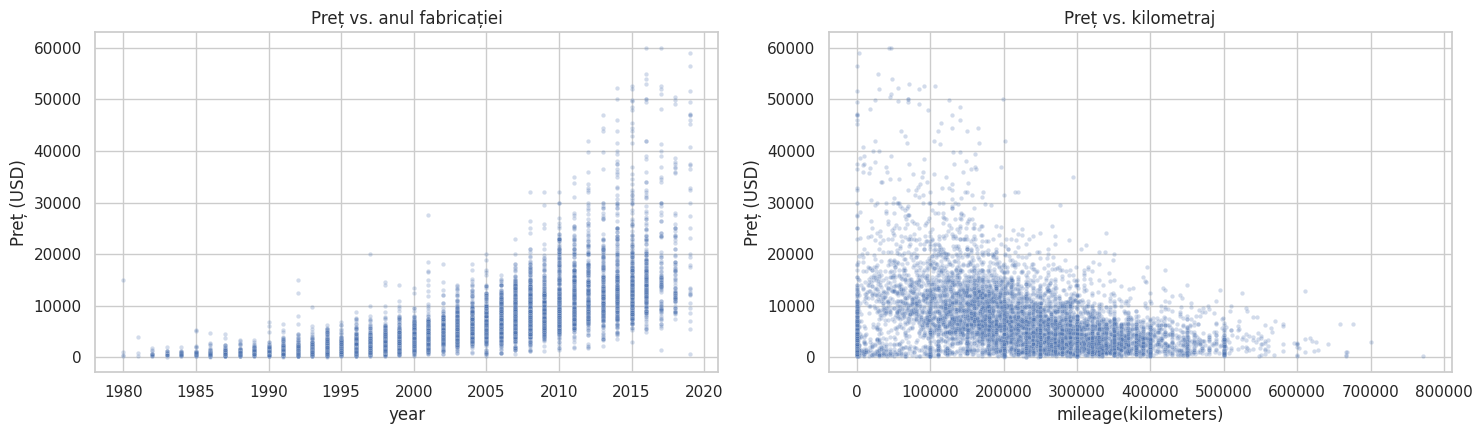

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sample = raw[(raw["priceUSD"] < 60000) & (raw["year"] >= 1980)].sample(8000, random_state=1)
sns.scatterplot(data=sample, x="year", y="priceUSD", alpha=.25, s=10, ax=axes[0])
axes[0].set_title("Preț vs. anul fabricației"); axes[0].set_ylabel("Preț (USD)")
s2 = sample[sample["mileage(kilometers)"] < 800000]
sns.scatterplot(data=s2, x="mileage(kilometers)", y="priceUSD", alpha=.25, s=10, ax=axes[1])
axes[1].set_title("Preț vs. kilometraj"); axes[1].set_ylabel("Preț (USD)")
plt.tight_layout(); plt.show()

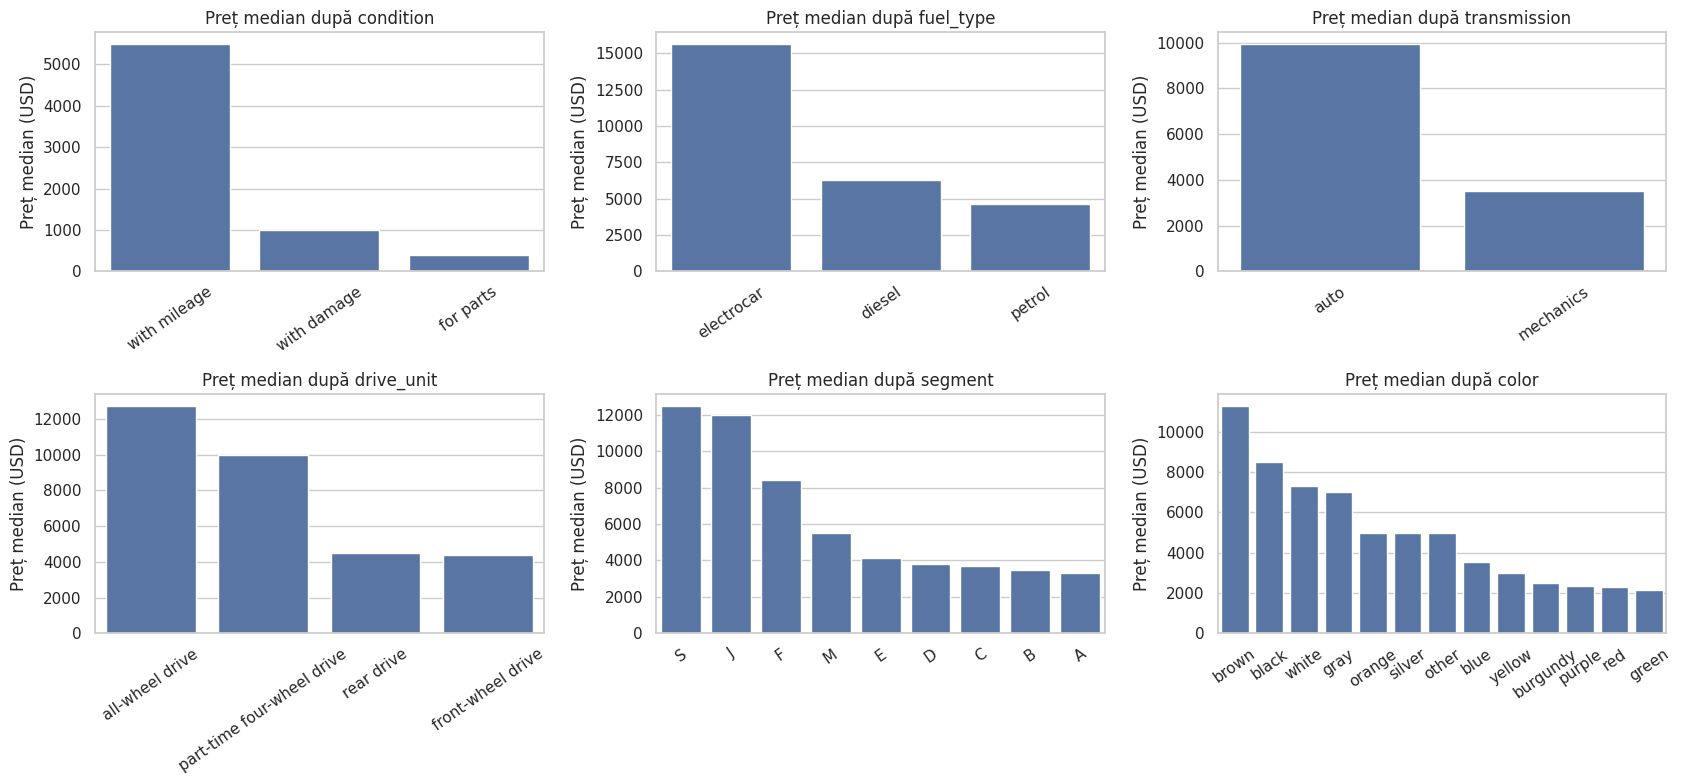

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, col in zip(axes.flat, ["condition", "fuel_type", "transmission", "drive_unit", "segment", "color"]):
    order = raw.groupby(col)["priceUSD"].median().sort_values(ascending=False).index
    sns.barplot(data=raw, x=col, y="priceUSD", order=order, estimator=np.median, errorbar=None, ax=ax, color="#4C72B0")
    ax.set_title(f"Preț median după {col}"); ax.set_ylabel("Preț median (USD)"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

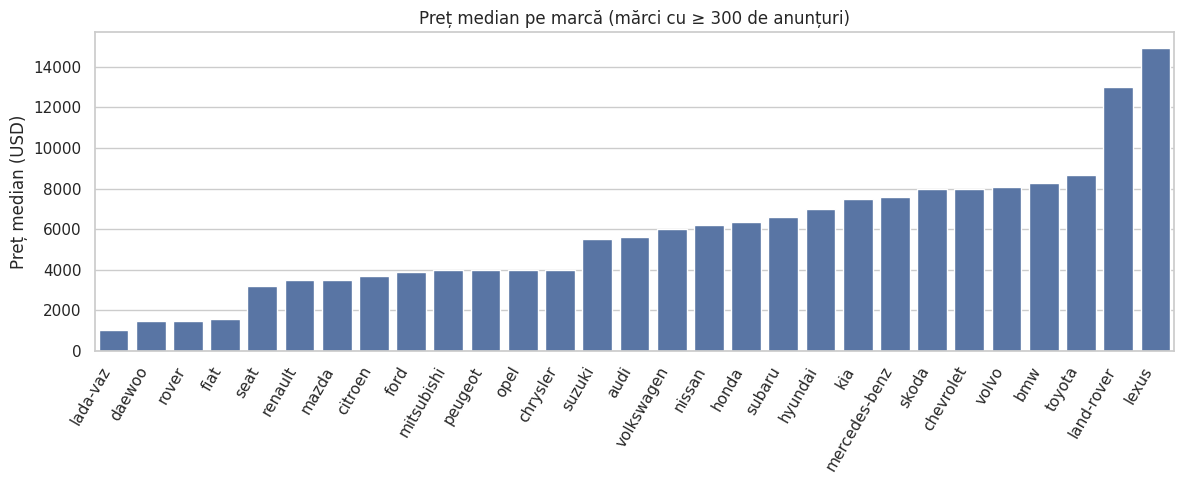

In [15]:
top_makes = raw.groupby("make")["priceUSD"].agg(["count", "median"]).query("count >= 300").sort_values("median")
plt.figure(figsize=(12, 5))
sns.barplot(x=top_makes.index, y=top_makes["median"], color="#4C72B0")
plt.title("Preț median pe marcă (mărci cu ≥ 300 de anunțuri)"); plt.ylabel("Preț median (USD)"); plt.xlabel("")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.show()

**Ce observ:**
- **Anul** este cel mai puternic factor: prețul crește aproape exponențial pentru mașinile mai noi.
- **Kilometrajul** are efect invers, dar mai „zgomotos”, fiind amestecat cu vârsta.
- **Starea**: mașinile „for parts” și „with damage” valorează de 5–10 ori mai puțin decât cele funcționale.
- **Transmisia automată**, **tracțiunea integrală** și **segmentele mari** (E, F, S, J) sunt asociate cu prețuri mai mari.
- **Culoarea** contează puțin. Diferențele vin probabil din alte cauze (ex. mașinile scumpe sunt des negre).
- **Marca** contează mult (ex. Lada față de Mercedes-Benz), iar **modelul** și mai mult, dar are >1.000 de valori.

## 5. Curățarea datelor (`src/data_cleaning.py`)

In [16]:
df = clean_data(raw)
print("Coloane:", df.columns.tolist())
df[["price_usd", "year", "mileage_km", "volume_cm3"]].describe()

[curățare] rânduri: 56244 → 55856 (eliminate 388)
Coloane: ['make', 'model', 'price_usd', 'year', 'condition', 'mileage_km', 'fuel_type', 'volume_cm3', 'color', 'transmission', 'drive_unit', 'segment']


,price_usd,year,mileage_km,volume_cm3
count,"55,856.0","55,856.0","53,093.0","55,856.0"
mean,"7,361.8","2,003.6","236,465.2","2,077.4"
std,"7,717.5",7.8,"119,397.0",719.0
min,100.0,"1,980.0",0.0,0.0
25%,"2,390.0","1,998.0","150,000.0","1,600.0"
50%,"5,399.0","2,004.0","235,000.0","1,984.0"
75%,"9,850.0","2,010.0","312,000.0","2,300.0"
max,"99,000.0","2,019.0","1,000,000.0","8,000.0"


In [17]:
print("Valori lipsă după curățare (vor fi completate în preprocesare):")
df.isna().sum()[lambda s: s > 0]

Valori lipsă după curățare (vor fi completate în preprocesare):


mileage_km    2763
drive_unit    1879
segment       5179
dtype: int64

## 6. Ingineria caracteristicilor (`src/feature_engineering.py`)

| Caracteristică nouă | Scop |
|---|---|
| `car_age` = 2020 − an | vârsta e mai intuitivă decât anul. 2020 = anul anunțurilor (cel mai nou an din date e 2019) |
| `mileage_per_year` | uzura: 200.000 km în 20 de ani e normal, în 3 ani nu |
| `engine_volume_liters` | forma obișnuită (1.6, 2.0) |
| `is_high_mileage` (> 300.000 km) | pragul psihologic la care cumpărătorii se tem de reparații |
| `is_newer_car` (≥ 2010) | generațiile mai noi au alt nivel de preț |
| `brand_model` (ex. `volkswagen_golf`) | modelul are sens doar împreună cu marca |

In [18]:
df = add_features(df)
df[["year", "car_age", "mileage_km", "mileage_per_year", "engine_volume_liters",
    "is_high_mileage", "is_newer_car", "brand_model", "price_usd"]].head()

,year,car_age,mileage_km,mileage_per_year,engine_volume_liters,is_high_mileage,is_newer_car,brand_model,price_usd
0,2008,12,"162,000.0","13,500.0",1.5,0.0,0,mazda_2,5500
1,2009,11,"120,000.0","10,909.1",1.3,0.0,0,mazda_2,5350
2,2009,11,"61,000.0","5,545.5",1.5,0.0,0,mazda_2,7000
3,2003,17,"265,000.0","15,588.2",1.4,0.0,0,mazda_2,3300
4,2008,12,"97,183.0","8,098.6",1.4,0.0,0,mazda_2,5200


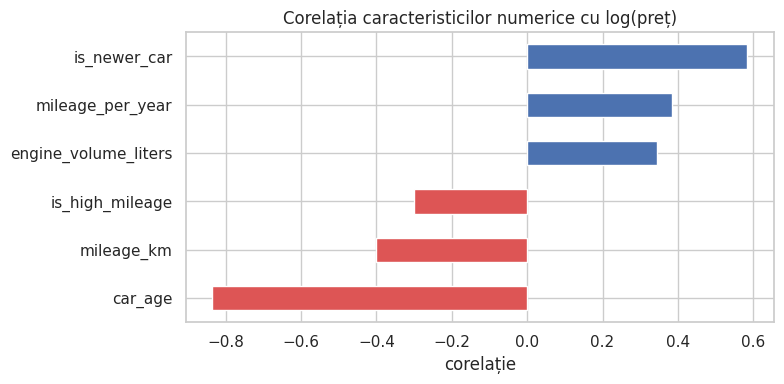

car_age                -0.8
mileage_km             -0.4
is_high_mileage        -0.3
engine_volume_liters    0.3
mileage_per_year        0.4
is_newer_car            0.6
Name: log_price, dtype: float64

In [19]:
# Verific dacă noile caracteristici au legătură cu prețul (corelație cu log(preț))
num_feats = ["car_age", "mileage_km", "mileage_per_year", "engine_volume_liters", "is_high_mileage", "is_newer_car"]
corr = df[num_feats].assign(log_price=np.log1p(df["price_usd"])).corr()["log_price"].drop("log_price").sort_values()
plt.figure(figsize=(8, 4))
corr.plot(kind="barh", color=["#DD5555" if v < 0 else "#4C72B0" for v in corr])
plt.title("Corelația caracteristicilor numerice cu log(preț)"); plt.xlabel("corelație")
plt.tight_layout(); plt.show()
corr.round(3)

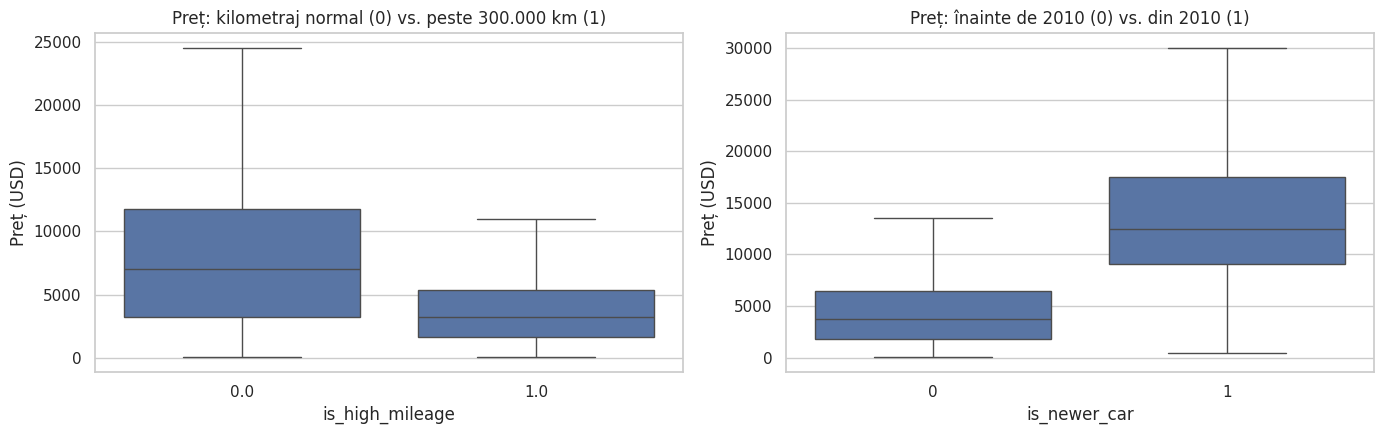

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="is_high_mileage", y="price_usd", showfliers=False, ax=axes[0])
axes[0].set_title("Preț: kilometraj normal (0) vs. peste 300.000 km (1)"); axes[0].set_ylabel("Preț (USD)")
sns.boxplot(data=df, x="is_newer_car", y="price_usd", showfliers=False, ax=axes[1])
axes[1].set_title("Preț: înainte de 2010 (0) vs. din 2010 (1)"); axes[1].set_ylabel("Preț (USD)")
plt.tight_layout(); plt.show()

**Concluzii EDA:**
- `car_age` are cea mai puternică legătură cu prețul (corelație ≈ −0,8 cu log(preț)).
- `is_newer_car` separă foarte clar prețurile (≈ +0,6): mașinile de după 2010 costă de câteva ori mai mult.
- **Surpriză:** `mileage_per_year` are o corelație **pozitivă** (≈ +0,4), deși mă așteptam la una negativă (mai multă uzură → preț mai mic).
  Explicația: mașinile noi au o vârstă mică la numitor, deci au mulți km/an și sunt și scumpe. Efectul real al uzurii
  este „ascuns” de vârstă. Un model liniar ar putea înțelege greșit această caracteristică. Arborii o pot folosi
  în combinație cu vârsta.
- Am întâlnit și **2.454 de mașini mai vechi de 2 ani cu sub 1.000 km**, mult mai multe decât credeam. Kilometrajul lor a devenit „necunoscut”.
- După curățare am **55.856 de mașini** gata pentru modelare. Continuarea este în `02_modeling.ipynb`.